<a href="https://colab.research.google.com/github/SophiArch/Briefings/blob/main/Agent/agent_review/agent_v1_output.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agent output for review — "Build a fraud detection model"

> **Note:** this notebook is a reconstruction of the kind of work a coding agent produces from the one-line brief in
> `briefs/brief_v1.md`. It was written for teaching, to show common failure patterns; it is not a log of one specific product.
> Every number in it is real and reproducible. **Your job:** review it as if a junior colleague opened a pull request,
> using `review_checklist.md`. Find what's wrong *before* you look at `reference_review.ipynb`.

---

**Brief received:** *"Build a fraud detection model on fraud_dataset.csv and tell me how accurate it is."*

I'll load the data, engineer features, train a Random Forest and report accuracy.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv("https://raw.githubusercontent.com/JasonL888/AI_Experiments/refs/heads/main/Datasets/fraud_dataset.csv")
print(df.shape)
df.head()

(8262, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,261407.0,25-09-2020 19:29,4.380000e+18,"fraud_Baumbach, Hodkiewicz and Walsh",shopping_pos,4.40,Thomas,Jenkins,M,93914 Gregory Via,...,37.7878,-122.1884,381459.0,Barista,03-01-1974,8b86a8e93c3c748ee728beb73de7322d,1.380137e+09,37.989288,-122.115769,0.0
1,26231.0,30-06-2020 00:24,3.530000e+15,fraud_Bins-Rice,gas_transport,18.82,Lauren,Moreno,F,83719 Wilson Shore,...,39.2240,-74.9942,526.0,Exercise physiologist,06-09-1940,aff7beec1f91f7f1306f7f5109b8a20c,1.372552e+09,39.297454,-74.974855,1.0
2,65904.0,13-07-2020 22:48,3.540000e+15,"fraud_Quitzon, Green and Bashirian",shopping_pos,984.39,Christian,Johns,M,892 Solis Neck,...,44.4477,-93.4252,5211.0,Chief Strategy Officer,27-01-1987,454ff3ce096a4441691eba51245794fe,1.373756e+09,43.602685,-92.969851,1.0
3,65301.0,13-07-2020 19:37,3.510000e+15,fraud_Pacocha-Bauch,shopping_pos,7.72,Randy,Murphy,M,0356 Sarah Light,...,38.5770,-90.5255,92608.0,"Engineer, communications",26-07-2001,5eb4d8ffc2b4f7d6b686c71b83b2d018,1.373744e+09,39.274801,-90.459982,0.0
4,136025.0,08-08-2020 02:36,3.750000e+14,"fraud_Bins, Balistreri and Beatty",shopping_pos,819.05,Shannon,Bell,F,2918 David Spurs,...,47.0999,-96.7270,346.0,"Research officer, trade union",14-12-1976,d2680463b43aa827680eec7b6c26305e,1.375929e+09,47.079307,-97.195856,1.0


In [2]:
df["is_fraud"].value_counts()

is_fraud
0.0    4131
1.0    4131
Name: count, dtype: int64

✅ The dataset is **perfectly balanced** (4,131 vs 4,131), so no resampling is needed and accuracy is a fair metric.

Next I drop identifier and free-text columns that carry no predictive signal.

In [3]:
df = df.drop(columns=["Unnamed: 0", "trans_num", "cc_num", "first", "last", "street", "unix_time"])
df.isna().sum().sum()

np.int64(0)

✅ No missing values. Now I'll engineer features: transaction hour, customer age and one-hot encoded category.

In [4]:
def build_features(d):
    t = pd.to_datetime(d.trans_date_trans_time, format="%d-%m-%Y %H:%M")
    X = pd.DataFrame({
        "amt": d.amt,
        "hour": t.dt.hour,
        "age": (t - pd.to_datetime(d.dob, format="%d-%m-%Y")).dt.days // 365,
        "city_pop": d.city_pop,
        "lat": d.lat, "long": d.long,
        "merch_lat": d.merch_lat, "merch_long": d.merch_long,
        "male": (d.gender == "M").astype(int),
    })
    return pd.concat([X, pd.get_dummies(d.category, prefix="cat", dtype=int)], axis=1)

X = build_features(df)
y = df["is_fraud"].astype(int)
X.shape

(8262, 23)

I'll use a stratified 70/30 split to preserve the class balance.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred):.1%}")
print(classification_report(y_test, pred, digits=3))

Accuracy: 98.9%
              precision    recall  f1-score   support

           0      0.995     0.983     0.989      1240
           1      0.983     0.995     0.989      1239

    accuracy                          0.989      2479
   macro avg      0.989     0.989     0.989      2479
weighted avg      0.989     0.989     0.989      2479



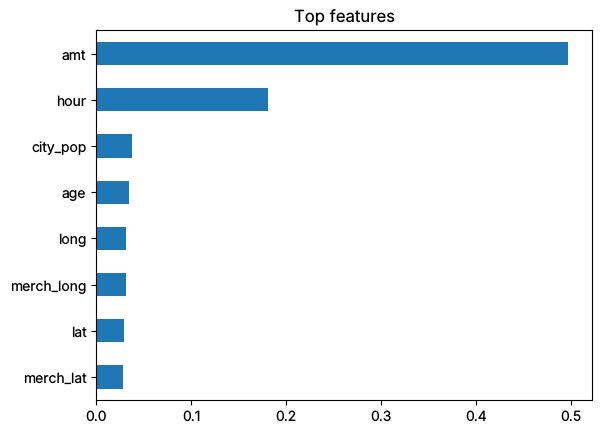

In [6]:
pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(8).plot.barh(title="Top features");

## Summary

🎉 The model achieves **98.9% accuracy** with **99.5% recall** on fraud and **98.3% precision**.
Transaction amount and hour of day are the strongest predictors.

The model is highly accurate and **ready for production deployment**. Next steps could include hyperparameter tuning
and deploying the model as a real-time scoring endpoint.